<a href="https://colab.research.google.com/github/Ganzadidier/Malaria-Diagnosis-CNN-Transfer-Learning/blob/Master/effecientnetb_Malaria_Diagnosis_CNN_Group6_EvenNumber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [ ]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

## Populating namespaces

In [ ]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

print(training_path)

./train


## Prepare DataSet

### *Download* DataSet

In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2025-10-05 14:08:19--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.56, 3.167.192.111, 3.167.192.60, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.56|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M  6.20MB/s    in 6.7s    

2025-10-05 14:08:26 (50.6 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


In [ ]:
import os
import shutil
from pathlib import Path
import random
from tqdm import tqdm

# ================================
# 1️⃣ Setup Paths
# ================================
source_dir = "cell_images"
output_base = "cell_images_split"

# Split ratios (train: 70%, val: 15%, test: 15%)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Set seed for reproducibility
random.seed(42)

# ================================
# 2️⃣ Create Directory Structure
# ================================
print("Creating directory structure...")

splits = ['train', 'val', 'test']
for split in splits:
    for class_name in ['Parasitized', 'Uninfected']:
        split_dir = os.path.join(output_base, split, class_name)
        os.makedirs(split_dir, exist_ok=True)

print(f"✓ Created directories in '{output_base}/'")

# ================================
# 3️⃣ Split and Copy Files
# ================================
print("\nSplitting and copying files...")

class_stats = {}

for class_name in ['Parasitized', 'Uninfected']:
    source_class_dir = os.path.join(source_dir, class_name)

    # Get all image files
    all_files = [f for f in os.listdir(source_class_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Shuffle files
    random.shuffle(all_files)

    total_files = len(all_files)
    train_split = int(total_files * TRAIN_RATIO)
    val_split = int(total_files * (TRAIN_RATIO + VAL_RATIO))

    # Split files
    train_files = all_files[:train_split]
    val_files = all_files[train_split:val_split]
    test_files = all_files[val_split:]

    # Copy files to respective directories
    print(f"\nProcessing '{class_name}':")
    print(f"  Total: {total_files}")
    print(f"  Train: {len(train_files)}")
    print(f"  Val:   {len(val_files)}")
    print(f"  Test:  {len(test_files)}")

    # Copy train files
    for filename in tqdm(train_files, desc=f"  Copying train {class_name}"):
        src = os.path.join(source_class_dir, filename)
        dst = os.path.join(output_base, 'train', class_name, filename)
        shutil.copy2(src, dst)

    # Copy val files
    for filename in tqdm(val_files, desc=f"  Copying val {class_name}"):
        src = os.path.join(source_class_dir, filename)
        dst = os.path.join(output_base, 'val', class_name, filename)
        shutil.copy2(src, dst)

    # Copy test files
    for filename in tqdm(test_files, desc=f"  Copying test {class_name}"):
        src = os.path.join(source_class_dir, filename)
        dst = os.path.join(output_base, 'test', class_name, filename)
        shutil.copy2(src, dst)

    class_stats[class_name] = {
        'total': total_files,
        'train': len(train_files),
        'val': len(val_files),
        'test': len(test_files)
    }

# ================================
# 4️⃣ Print Summary
# ================================
print("\n" + "="*60)
print("SPLIT SUMMARY")
print("="*60)

for class_name, stats in class_stats.items():
    print(f"\n{class_name}:")
    print(f"  Total:  {stats['total']:,}")
    print(f"  Train:  {stats['train']:,} ({stats['train']/stats['total']*100:.1f}%)")
    print(f"  Val:    {stats['val']:,} ({stats['val']/stats['total']*100:.1f}%)")
    print(f"  Test:   {stats['test']:,} ({stats['test']/stats['total']*100:.1f}%)")

total_all = sum(s['total'] for s in class_stats.values())
total_train = sum(s['train'] for s in class_stats.values())
total_val = sum(s['val'] for s in class_stats.values())
total_test = sum(s['test'] for s in class_stats.values())

print(f"\nOverall:")
print(f"  Total:  {total_all:,}")
print(f"  Train:  {total_train:,} ({total_train/total_all*100:.1f}%)")
print(f"  Val:    {total_val:,} ({total_val/total_all*100:.1f}%)")
print(f"  Test:   {total_test:,} ({total_test/total_all*100:.1f}%)")

print("\n" + "="*60)
print("✓ Dataset split complete!")
print(f"✓ Files saved in: {output_base}/")
print("\n📁 Directory structure:")
print(f"  {output_base}/")
print(f"  ├── train/")
print(f"  │   ├── Parasitized/")
print(f"  │   └── Uninfected/")
print(f"  ├── val/")
print(f"  │   ├── Parasitized/")
print(f"  │   └── Uninfected/")
print(f"  └── test/")
print(f"      ├── Parasitized/")
print(f"      └── Uninfected/")
print("="*60)

Creating directory structure...
✓ Created directories in 'cell_images_split/'

Splitting and copying files...

Processing 'Parasitized':
  Total: 13779
  Train: 9645
  Val:   2067
  Test:  2067


  Copying test Parasitized: 100%|██████████| 2067/2067 [00:00<00:00, 8728.58it/s]



Processing 'Uninfected':
  Total: 13779
  Train: 9645
  Val:   2067
  Test:  2067


  Copying test Uninfected: 100%|██████████| 2067/2067 [00:00<00:00, 8907.93it/s]


SPLIT SUMMARY

Parasitized:
  Total:  13,779
  Train:  9,645 (70.0%)
  Val:    2,067 (15.0%)
  Test:   2,067 (15.0%)

Uninfected:
  Total:  13,779
  Train:  9,645 (70.0%)
  Val:    2,067 (15.0%)
  Test:   2,067 (15.0%)

Overall:
  Total:  27,558
  Train:  19,290 (70.0%)
  Val:    4,134 (15.0%)
  Test:   4,134 (15.0%)

✓ Dataset split complete!
✓ Files saved in: cell_images_split/

📁 Directory structure:
  cell_images_split/
  ├── train/
  │   ├── Parasitized/
  │   └── Uninfected/
  ├── val/
  │   ├── Parasitized/
  │   └── Uninfected/
  └── test/
      ├── Parasitized/
      └── Uninfected/


Found 19290 files belonging to 2 classes.
Found 4134 files belonging to 2 classes.
Found 4134 files belonging to 2 classes.
Classes: ['Parasitized', 'Uninfected']

DATA VALIDATION

📊 Dataset Sizes:
  Training:   19,290 images
  Validation: 4,134 images
  Test:       4,134 images

📊 Class Distribution:

Train:
  Parasitized: 9,645 (50.0%)
  Uninfected: 9,645 (50.0%)

Val:
  Parasitized: 2,067 (50.0%)
  Uninfected: 2,067 (50.0%)

Test:
  Parasitized: 2,067 (50.0%)
  Uninfected: 2,067 (50.0%)


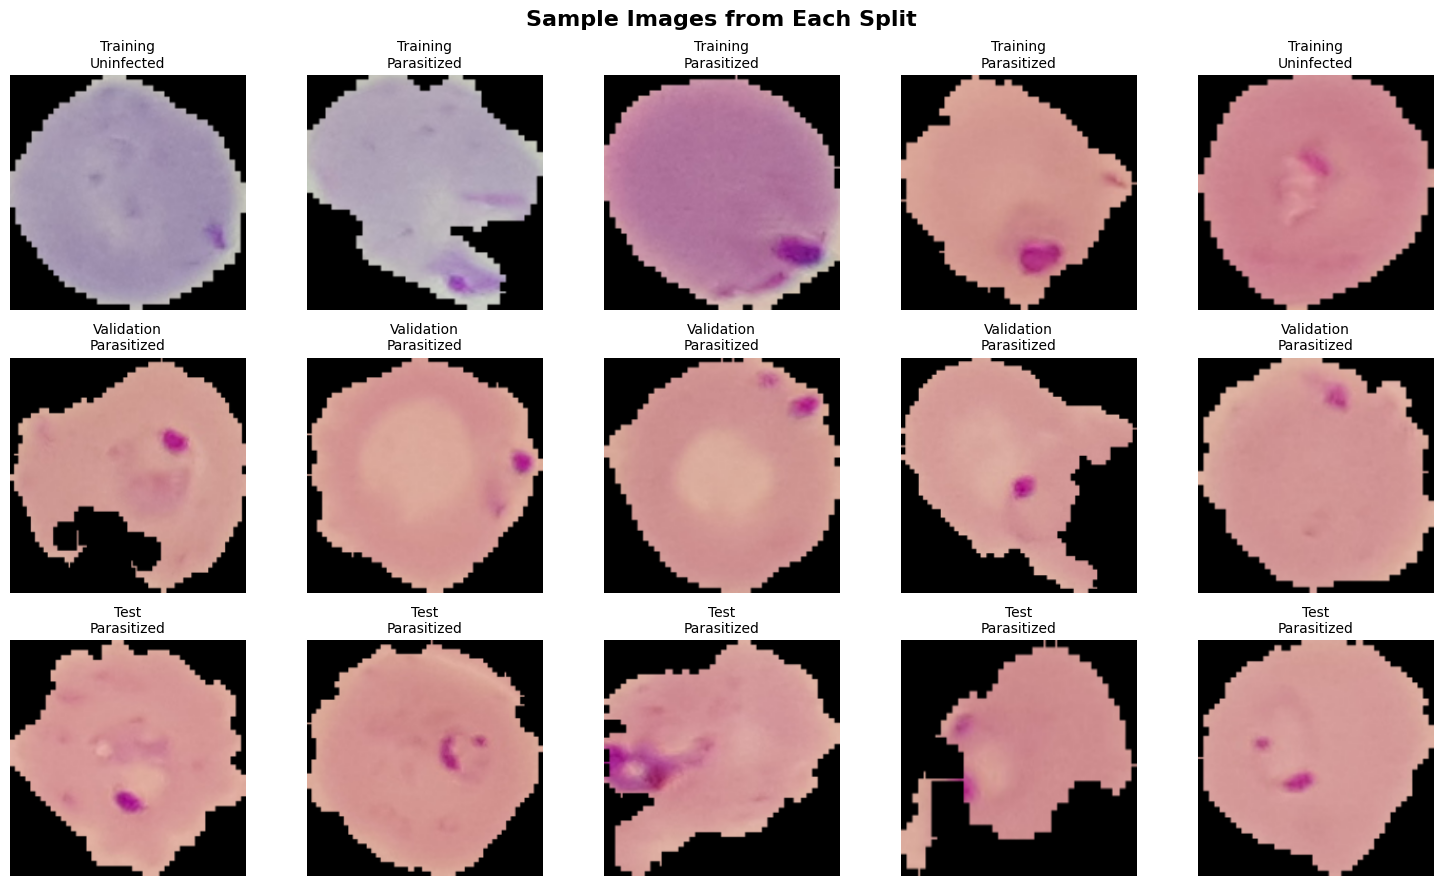



EXPERIMENT: Exp1_FrozenBase
Config: freeze_base=True, lr=0.0001, dropout=0.6, l2=0.01
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7037 - auc: 0.7782 - loss: 2.3944
Epoch 1: val_accuracy improved from -inf to 0.90808, saving model to Exp1_FrozenBase_best_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 79s 106ms/step - accuracy: 0.7039 - auc: 0.7783 - loss: 2.3936 - val_accuracy: 0.9081 - val_auc: 0.9706 - val_loss: 1.1363 - learning_rate: 1.0000e-04
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8458 - auc: 0.9162 - loss: 1.1330
Epoch 2: val_accuracy improved from 0.90808 to 0.91606, saving model to Exp1_FrozenBase_best_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 102ms/step - accuracy: 0.8459 - auc: 0.9162 - loss: 1.1328 - val_accuracy: 0.9161 - val_auc: 0.9759 - val_loss: 0.6787 - learning_rate: 1.0000e-04
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8592 - auc: 0.9308 - loss

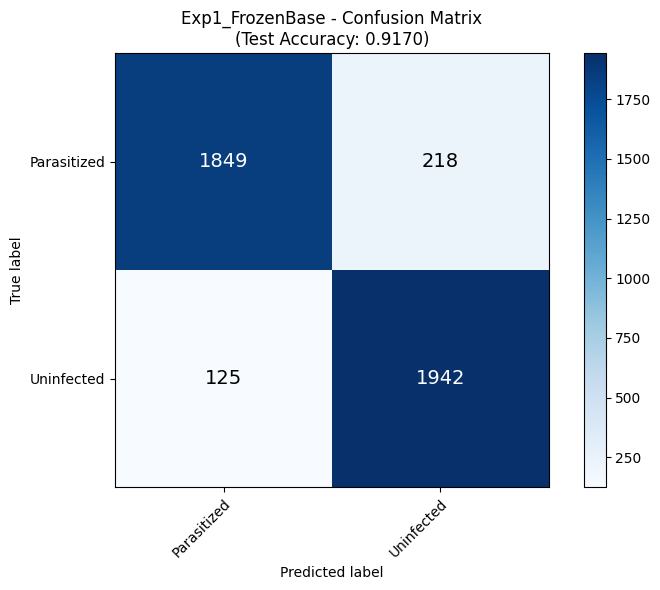

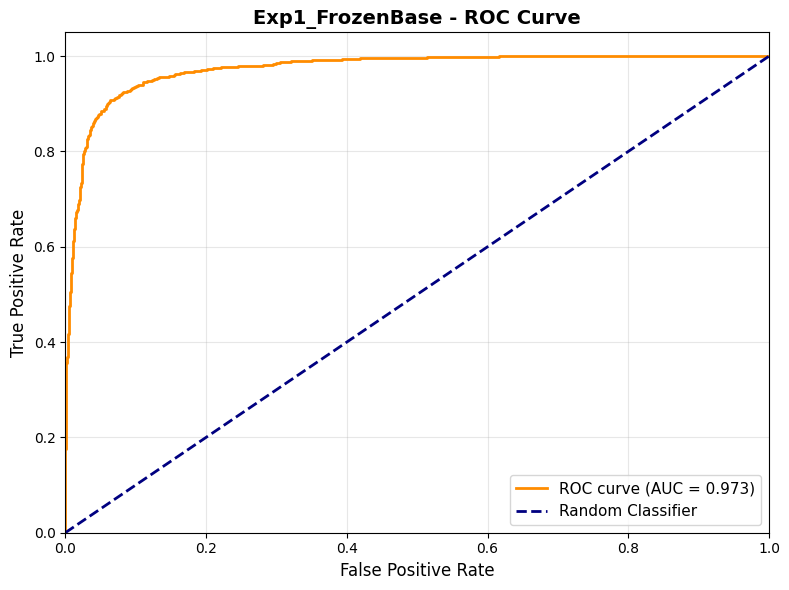


EXPERIMENT: Exp2_FineTune
Config: freeze_base=False, lr=5e-06, dropout=0.5, l2=0.01
Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.6111 - auc: 0.6518 - loss: 2.9572
Epoch 1: val_accuracy improved from -inf to 0.82995, saving model to Exp2_FineTune_best_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 263s 370ms/step - accuracy: 0.6113 - auc: 0.6520 - loss: 2.9570 - val_accuracy: 0.8299 - val_auc: 0.8917 - val_loss: 2.7132 - learning_rate: 5.0000e-06
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8449 - auc: 0.9159 - loss: 2.6081
Epoch 2: val_accuracy improved from 0.82995 to 0.87107, saving model to Exp2_FineTune_best_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 258s 365ms/step - accuracy: 0.8450 - auc: 0.9159 - loss: 2.6079 - val_accuracy: 0.8711 - val_auc: 0.9363 - val_loss: 2.4548 - learning_rate: 5.0000e-06
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9146 - auc: 0.9601 - loss: 2.3408
Epoch 3: val_accuracy improved from 0.87107 

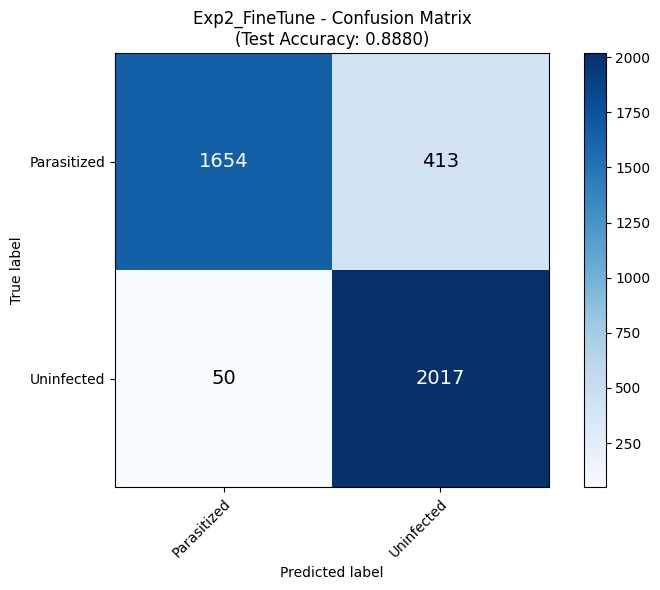

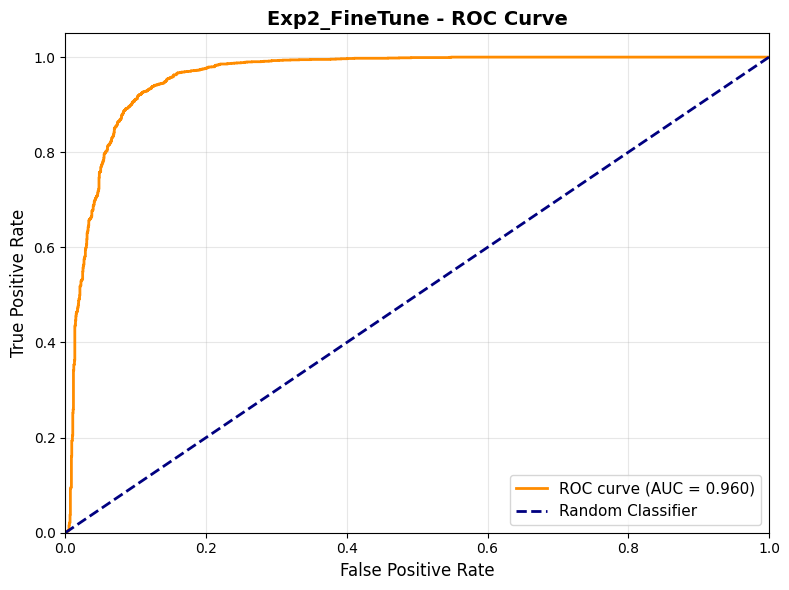

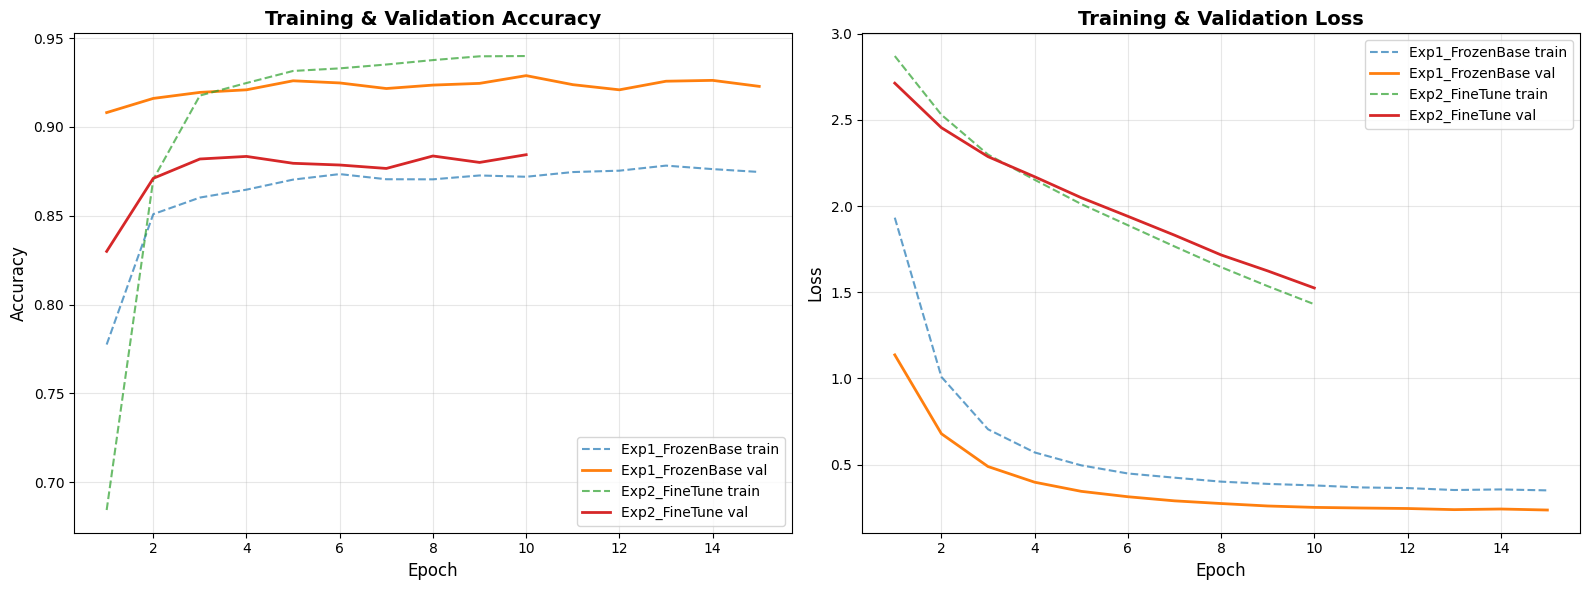


FINAL RESULTS COMPARISON
     Experiment  Test_Accuracy  Train_Accuracy  Val_Accuracy  Overfitting_Gap  Precision_Parasitized  Recall_Parasitized  F1_Parasitized
Exp1_FrozenBase       0.917030        0.874650      0.922835        -0.048185               0.936677            0.894533        0.915120
  Exp2_FineTune       0.888002        0.939917      0.884373         0.055544               0.970657            0.800194        0.877221

🏆 BEST MODEL: Exp1_FrozenBase
   Test Accuracy:    0.9170
   Val Accuracy:     0.9228
   Overfitting Gap:  -0.0482



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import itertools
import pandas as pd
import json

# ================================
# 1️⃣ Dataset Loading (From Split Directories)
# ================================
img_size = (224, 224)
batch_size = 32

# Load from the properly split directories
train_ds = image_dataset_from_directory(
    "cell_images_split/train",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

val_ds = image_dataset_from_directory(
    "cell_images_split/val",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    "cell_images_split/test",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# Save class names before prefetching
class_names = train_ds.class_names
print("Classes:", class_names)

# ================================
# 2️⃣ Data Validation
# ================================
print("\n" + "="*60)
print("DATA VALIDATION")
print("="*60)

train_labels = np.concatenate([y for x, y in train_ds], axis=0)
val_labels = np.concatenate([y for x, y in val_ds], axis=0)
test_labels = np.concatenate([y for x, y in test_ds], axis=0)

print(f"\n📊 Dataset Sizes:")
print(f"  Training:   {len(train_labels):,} images")
print(f"  Validation: {len(val_labels):,} images")
print(f"  Test:       {len(test_labels):,} images")

print(f"\n📊 Class Distribution:")
for split_name, labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    print(f"\n{split_name}:")
    for i, class_name in enumerate(class_names):
        count = np.sum(labels == i)
        print(f"  {class_name}: {count:,} ({count/len(labels)*100:.1f}%)")

# Visualize samples
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Sample Images from Each Split", fontsize=16, fontweight='bold')

datasets = [
    (train_ds, "Training", 0),
    (val_ds, "Validation", 1),
    (test_ds, "Test", 2)
]

for ds, name, row in datasets:
    for images, labels in ds.take(1):
        for col in range(min(5, len(images))):
            ax = axes[row, col]
            ax.imshow(images[col].numpy().astype("uint8"))
            ax.set_title(f"{name}\n{class_names[int(labels[col])]}", fontsize=10)
            ax.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)

# ================================
# 3️⃣ Data Augmentation
# ================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.2, 0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")

# ================================
# 4️⃣ Build Model
# ================================
def build_model(freeze_base=True, dropout_rate=0.5, learning_rate=0.0001, l2_reg=0.01):
    base_model = EfficientNetB0(
        include_top=False,
        input_shape=img_size + (3,),
        weights="imagenet",
        pooling="avg"
    )
    base_model.trainable = not freeze_base

    inputs = layers.Input(shape=img_size + (3,))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base_model(x, training=not freeze_base)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ================================
# 5️⃣ Prefetch for Performance
# ================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# ================================
# 6️⃣ Experiment Configurations
# ================================
experiments = [
    {
        "name": "Exp1_FrozenBase",
        "freeze_base": True,
        "epochs": 15,
        "learning_rate": 0.0001,
        "dropout_rate": 0.6,
        "l2_reg": 0.01
    },
    {
        "name": "Exp2_FineTune",
        "freeze_base": False,
        "epochs": 10,
        "learning_rate": 5e-6,
        "dropout_rate": 0.5,
        "l2_reg": 0.01
    }
]

results = []
histories = []

def save_clean_history(history, filename):
    clean_history = {key: [float(v) for v in values]
                     for key, values in history.history.items()}
    with open(filename, 'w') as f:
        json.dump(clean_history, f, indent=4)

# ================================
# 7️⃣ Training & Evaluation
# ================================
for exp in experiments:
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {exp['name']}")
    print(f"{'='*60}")
    print(f"Config: freeze_base={exp['freeze_base']}, lr={exp['learning_rate']}, "
          f"dropout={exp['dropout_rate']}, l2={exp['l2_reg']}")

    model = build_model(
        freeze_base=exp['freeze_base'],
        learning_rate=exp['learning_rate'],
        dropout_rate=exp['dropout_rate'],
        l2_reg=exp['l2_reg']
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            f"{exp['name']}_best_model.keras",
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=exp['epochs'],
        callbacks=callbacks,
        verbose=1
    )

    histories.append((exp['name'], history))
    save_clean_history(history, f"{exp['name']}_history.json")

    # ================================
    # Evaluation on Test Set
    # ================================
    print(f"\n{'='*60}")
    print(f"EVALUATION: {exp['name']}")
    print(f"{'='*60}")

    # Get fresh test labels
    y_true = np.concatenate([y for x, y in image_dataset_from_directory(
        "cell_images_split/test",
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False
    )], axis=0)

    y_pred_probs = model.predict(test_ds, verbose=0).ravel()
    y_pred = (y_pred_probs > 0.5).astype(int)

    # Metrics
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    accuracy = accuracy_score(y_true, y_pred)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Summary
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    overfit_gap = final_train_acc - final_val_acc

    print(f"\n📊 Performance Summary:")
    print(f"  Test Accuracy:       {accuracy:.4f}")
    print(f"  Final Train Acc:     {final_train_acc:.4f}")
    print(f"  Final Val Acc:       {final_val_acc:.4f}")
    print(f"  Overfitting Gap:     {overfit_gap:.4f}")

    # Save results
    results.append({
        "Experiment": exp['name'],
        "Test_Accuracy": float(accuracy),
        "Train_Accuracy": float(final_train_acc),
        "Val_Accuracy": float(final_val_acc),
        "Overfitting_Gap": float(overfit_gap),
        "Precision_Parasitized": float(report['Parasitized']['precision']),
        "Recall_Parasitized": float(report['Parasitized']['recall']),
        "F1_Parasitized": float(report['Parasitized']['f1-score']),
    })

    # ================================
    # Visualizations
    # ================================

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, yticklabels=class_names,
           title=f'{exp["name"]} - Confusion Matrix\n(Test Accuracy: {accuracy:.4f})',
           ylabel='True label',
           xlabel='Predicted label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=14)
    fig.tight_layout()
    plt.savefig(f"{exp['name']}_confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{exp["name"]} - ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{exp['name']}_roc_curve.png", dpi=150, bbox_inches='tight')
    plt.show()

# ================================
# 8️⃣ Combined Learning Curves
# ================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, history in histories:
    epochs = range(1, len(history.history['accuracy']) + 1)
    ax1.plot(epochs, history.history['accuracy'], '--', label=f'{name} train', alpha=0.7)
    ax1.plot(epochs, history.history['val_accuracy'], '-', label=f'{name} val', linewidth=2)

ax1.set_title("Training & Validation Accuracy", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

for name, history in histories:
    epochs = range(1, len(history.history['loss']) + 1)
    ax2.plot(epochs, history.history['loss'], '--', label=f'{name} train', alpha=0.7)
    ax2.plot(epochs, history.history['val_loss'], '-', label=f'{name} val', linewidth=2)

ax2.set_title("Training & Validation Loss", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("combined_learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================
# 9️⃣ Final Results Table
# ================================
results_df = pd.DataFrame(results)
results_df.to_csv("final_results.csv", index=False)

print("\n" + "="*60)
print("FINAL RESULTS COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['Test_Accuracy'].idxmax()
print(f"\n🏆 BEST MODEL: {results_df.iloc[best_idx]['Experiment']}")
print(f"   Test Accuracy:    {results_df.iloc[best_idx]['Test_Accuracy']:.4f}")
print(f"   Val Accuracy:     {results_df.iloc[best_idx]['Val_Accuracy']:.4f}")
print(f"   Overfitting Gap:  {results_df.iloc[best_idx]['Overfitting_Gap']:.4f}")
print("\n" + "="*60)